In [1]:
import pandas as pd
from os import scandir
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import pickle
# custom
import cvTools.cv_interaction as cst

# Results
Otsu and H thresholding seems the best choice, even though there still is room to improve

# Thresholding - HSV

## Playing with parameters

In [19]:
with open('thresh_HSV.pickle', 'rb') as fin: thresh = pickle.load(fin)

### bad example

In [21]:
low = (0, 110, 50)
high = (23, 255, 210)
low, high, thresh = cst.threshing('data/NV/ISIC_0000039_downsampled.jpg', 'HSV', thresh=thresh, low=low, high=high)

In [2]:
low, high= cst.threshing('data/MEL/ISIC_0000026_downsampled.jpg', 'HSV')

In [4]:
low, high = cst.threshing('data/MEL/ISIC_0025963.jpg', 'HSV')

### Good example

In [20]:
low = (0, 110, 50)
high = (23, 255, 210)
low, high, thresh = cst.threshing('data/NV/ISIC_0008236_downsampled.jpg', 'HSV', thresh=thresh, low=low, high=high)


In [6]:
low, high, thresh = cst.threshing('data/NV/ISIC_0000001.jpg', 'HSV', thresh=thresh, low=low, high=high)

---

In [8]:
with open('thresh_HSV.pickle', 'wb') as fout: pickle.dump(thresh, fout, protocol=-1)

## Application

In [11]:
low = (0, 110, 50)
high = (23, 255, 210)
low, high = cst.threshing('data/NV/ISIC_0000015.jpg', 'HSV', low=low, high=high)

In [16]:
img_path = 'data/NV/ISIC_0000010.jpg'
img = cv.imread(img_path)
res = cst.hist_match(img, cv.imread('data/NV/ISIC_0000015.jpg'))
res = cv.cvtColor(res, cv.COLOR_BGR2HSV)
mask = cv.inRange(res, (0, 110, 50), (23, 255, 210))
res = cv.bitwise_and(res, res, mask=mask)
res = cv.cvtColor(res, cv.COLOR_HSV2BGR)

In [17]:
cst.show([img, res], ['original', 'matched'])

# Thresholding - LAB

In [8]:
with open('thresh_LAB.pickle', 'rb') as fin: thresh = pickle.load(fin)

In [68]:
low, high = cst.threshing('data/MEL/ISIC_0014366_downsampled.jpg', 'LAB')


In [72]:
img = cv.imread('data/MEL/ISIC_0014366_downsampled.jpg')
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
lab[..., 0] = lab[..., 0] // 3
lab = cv.cvtColor(lab, cv.COLOR_LAB2BGR)
cst.show([img, lab], ['original', 'landsf'])

# Thresholding - Gray

In [2]:
img_path = 'data/MEL/ISIC_0014366_downsampled.jpg'
low = 0
high = 0

img = cv.imread(img_path)
win_name = img_path[5:-4]
cv.namedWindow('Original - ' + win_name, cv.WINDOW_NORMAL)
cv.namedWindow((touch := 'Masked - ' + win_name), cv.WINDOW_NORMAL)
M = 255
cv.createTrackbar('Value - Low', touch, 0, M, cst.still)
cv.createTrackbar('Value - High', touch, 0, M, cst.still)
if low is not None: cv.setTrackbarPos('Value - Low', touch, low)
if high is not None: cv.setTrackbarPos('Value - High', touch, high)

while True:
    low = cv.getTrackbarPos('Value - Low', touch)
    high = cv.getTrackbarPos('Value - High', touch)
    res = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    mask = cv.inRange(res, low, high)
    res = cv.bitwise_and(res, res, mask=mask)
    res = cv.cvtColor(res, cv.COLOR_GRAY2BGR)
    cv.imshow('Original - ' + win_name, img)
    cv.imshow(touch, res)
    if cv.waitKey(20) & 0xFF == 27: break
cv.destroyAllWindows()

# Thresholding - Otsu

In [5]:
img_path = 'data/MEL/ISIC_0062181.jpg'
img = cv.imread(img_path)

## median filter to remove hair & artifacts
temp = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
# for _ in range(5): temp = cv.medianBlur(temp, 5)
_, lens = cv.threshold(temp, 10, 255, cv.THRESH_BINARY) # throw away borders
rows = [cv.hasNonZero(lens[i]) for i in range(lens.shape[0])]
cols = [cv.hasNonZero(lens[:,i]) for i in range(lens.shape[1])]
# mean = cv.mean(temp, lens)
# temp = cv.add(temp, mean, temp, mask=cv.bitwise_not(lens))[rows][:, cols]
temp = cv.add(temp, cv.bitwise_not(lens))[rows][:, cols]
cst.show([temp])
temp = cv.dilate(temp, np.ones((5,5), dtype=np.uint8),iterations=1)

## otsu
_, otsu = cv.threshold(temp, 0, 255, cv.THRESH_BINARY_INV+cv.THRESH_OTSU)
# _, threshf = cv.threshold(temp, 0, 255, cv.THRESH_BINARY_INV+cv.THRESH_OTSU)

## h thresholding
# temp2 = cv.cvtColor(img[rows][:, cols], cv.COLOR_BGR2HSV)
# _, thresh1 = cv.threshold(temp2[..., 0], 23, 255, cv.THRESH_BINARY_INV)
# _, thresh2 = cv.threshold(temp2[..., 0], 160, 255, cv.THRESH_BINARY)
# threshH = cv.bitwise_or(thresh1, thresh2)

# put them together
# threshf = cv.bitwise_and(threshH, otsu)
# trim zero rows and columns
# rows2 = [cv.hasNonZero(threshf[i]) for i in range(threshf.shape[0])]
# cols2 = [cv.hasNonZero(threshf[:,i]) for i in range(threshf.shape[1])]
rows2 = [cv.hasNonZero(otsu[i]) for i in range(otsu.shape[0])]
cols2 = [cv.hasNonZero(otsu[:,i]) for i in range(otsu.shape[1])]
res = cv.bitwise_and(img[rows][:, cols], img[rows][:, cols], mask=otsu)[rows2][:, cols2]
cst.show([img, temp, otsu, res], ['img', 'filter', 'otsu', 'res'])

# Adaptive Thresholding

In [40]:
img_path = 'data/NV/ISIC_0072007.jpg'
img = cv.imread(img_path)

## median filter to remove hair & artifacts
temp = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
# for _ in range(5): temp = cv.medianBlur(temp, 5)
temp = cv.dilate(temp, np.ones((5,5), dtype=np.uint8),iterations=2)

thresh = cv.adaptiveThreshold(temp, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY_INV, 101, 10)
## h thresholding
temp2 = cv.cvtColor(img, cv.COLOR_BGR2HSV)
_, thresh1 = cv.threshold(temp2[..., 0], 23, 255, cv.THRESH_BINARY_INV)
_, thresh2 = cv.threshold(temp2[..., 0], 160, 255, cv.THRESH_BINARY)
threshH = cv.bitwise_or(thresh1, thresh2)

## put them together
threshf = cv.bitwise_and(threshH, thresh)
## trim zero rows and columns
rows = [cv.hasNonZero(threshf[i]) for i in range(threshf.shape[0])]
cols = [cv.hasNonZero(threshf[:,i]) for i in range(threshf.shape[1])]
res = cv.bitwise_and(img, img, mask=threshf)[rows][:, cols]
cst.show([img, temp, thresh, res], ['img', 'filter', 'otsu', 'res'])

# Watershed

In [35]:
img_path = 'data/MEL/ISIC_0000035_downsampled.jpg'
img = cv.imread(img_path)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(gray,0,255,cv.THRESH_BINARY_INV+cv.THRESH_OTSU)
# cst.show([thresh])
kernel = np.ones((3,3),np.uint8)
opening = cv.morphologyEx(thresh,cv.MORPH_OPEN,kernel, iterations = 2)
 
# sure background area
sure_bg = cv.dilate(opening,kernel,iterations=3)
 
# Finding sure foreground area
dist_transform = cv.distanceTransform(opening,cv.DIST_L2,5)
ret, sure_fg = cv.threshold(dist_transform,0.7*dist_transform.max(),255,0)
 
# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv.subtract(sure_bg, sure_fg)
# cst.show([sure_fg, unknown], ['sure', 'not sure'])
ret, markers = cv.connectedComponents(sure_fg)
# plt.imshow(markers)
# plt.show()
 
# Add one to all labels so that sure background is not 0, but 1
markers = markers+1
markers[:201, :] = 0 
markers[-200:, :] = 0 
markers[:, :201] = 0
markers[:, -200:] = 0
# Now, mark the region of unknown with zero
markers[unknown==255] = 0
pre = np.copy(markers)
markers = cv.watershed(img,markers)
img[markers == -1] = [0,0,255]

In [36]:
cst.show([img])

In [50]:
cst.show([img])

# KMeans

In [53]:
img = cv.imread('data/NV/ISIC_0007796_downsampled.jpg')
# show(img)
Z = img.reshape((-1, 3)).astype(np.float32)
img = cv.cvtColor(cv.imread('data/NV/ISIC_0007796_downsampled.jpg'), cv.COLOR_BGR2HSV)
prova = cv.inRange(img, (0, 100, 16), (17, 255, 200))

# define criteria, number of clusters(K) and apply kmeans()
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 2
_, label, center = cv.kmeans(Z,K,None,criteria,10, cv.KMEANS_PP_CENTERS)
 
# Now convert back into uint8, and make original image
center = np.uint8(center)

# darker region
arg_dark = np.argmin(center[..., 0])
flat_idx = np.nonzero(label.flatten() == arg_dark)

# mask for image
mask = np.zeros(img.shape[0] * img.shape[1], dtype=np.uint8)
mask[flat_idx] = 255
mask = mask.reshape(img.shape[:2])

masked_img = cv.bitwise_and(img, img, mask=mask)

# bilateral filter
bil = cv.bilateralFilter(masked_img, d=9, sigmaColor=10, sigmaSpace=39)
# masked_img = cv.cvtColor(masked_img, cv.COLOR_BGR2GRAY)
masked_img = cv.cvtColor(masked_img, cv.COLOR_BGR2LAB)
bil = cv.cvtColor(bil, cv.COLOR_BGR2LAB)
# create a CLAHE object (Arguments are optional).
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(masked_img[..., 0])
cl2 = clahe.apply(bil[..., 0])
bil[..., 0] = cl2
masked_img[..., 0] = cl1

# out = np.hstack((masked_img, cl1))
# show(out)
cst.show([cv.cvtColor(masked_img, cv.COLOR_LAB2BGR)])
cst.show([cv.cvtColor(bil, cv.COLOR_LAB2BGR)])

## ?

In [28]:
img = cv.imread('data/NV/ISIC_0007796_downsampled.jpg')
show(img)
Z = img.reshape((-1, 3)).astype(np.float32)

# define criteria, number of clusters(K) and apply kmeans()
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 2
_, label, center = cv.kmeans(Z,K,None,criteria,10, cv.KMEANS_PP_CENTERS)
 
# Now convert back into uint8, and make original image
center = np.uint8(center)

# darker region
arg_dark = np.argmin(center[..., 0])
flat_idx = np.nonzero(label.flatten() == arg_dark)

# mask for image
mask = np.zeros(img.shape[0] * img.shape[1], dtype=np.uint8)
mask[flat_idx] = 255
mask = mask.reshape(img.shape[:2])

masked_img = cv.bitwise_and(img, img, mask=mask)

# bilateral filter
bil = cv.bilateralFilter(masked_img, d=9, sigmaColor=10, sigmaSpace=39)
# masked_img = cv.cvtColor(masked_img, cv.COLOR_BGR2GRAY)
masked_img = cv.cvtColor(masked_img, cv.COLOR_BGR2LAB)
bil = cv.cvtColor(bil, cv.COLOR_BGR2LAB)
# create a CLAHE object (Arguments are optional).
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(masked_img[..., 0])
cl2 = clahe.apply(bil[..., 0])
bil[..., 0] = cl2
masked_img[..., 0] = cl1

# out = np.hstack((masked_img, cl1))
# show(out)
show(cv.cvtColor(masked_img, cv.COLOR_LAB2BGR))
show(cv.cvtColor(bil, cv.COLOR_LAB2BGR))

In [27]:
show(masked_img)

In [37]:
bil = cv.bilateralFilter(masked_img, d=9, sigmaColor=10, sigmaSpace=39)
show(np.hstack((masked_img, bil)))

# DL

In [58]:
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
import torch
from PIL import Image
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
else: device = torch.device('cpu')
    
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
transforms = weights.transforms()
img = cv.imread('data/MEL/ISIC_0014366_downsampled.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img = Image.fromarray(img)
img = transforms(img)
images = [img.to(device)]

model = maskrcnn_resnet50_fpn(weights=weights, progress=False).to(device)
model = model.eval()

output = model(images)
print(output)

[{'boxes': tensor([[  33.8851,    0.0000,  945.1514,  678.3564],
        [ 451.1136,  227.4170,  529.5609,  419.6414],
        [   0.0000,    0.0000, 1024.0000,  675.5554]], device='cuda:0',
       grad_fn=<StackBackward0>), 'labels': tensor([ 1,  1, 65], device='cuda:0'), 'scores': tensor([0.1259, 0.0945, 0.0899], device='cuda:0', grad_fn=<IndexBackward0>), 'masks': tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
  

In [59]:
mask = output[0]['masks'].to('cpu')

In [62]:
mask = mask.squeeze(1)

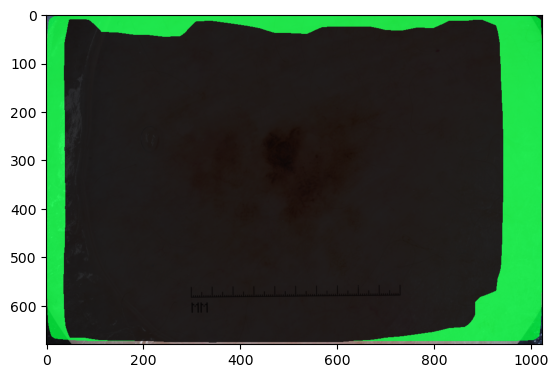

In [66]:
from torchvision.utils import draw_segmentation_masks
plt.imshow(torch.movedim(draw_segmentation_masks(img, mask > 0.5), 0, -1))
plt.show()

In [11]:
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights
import torch

if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
else: device = torch.device('cpu')

img = cv.imread('data/MEL/ISIC_0014366_downsampled.jpg')
# img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
# img = torch.tensor(img, dtype=torch.float32).to(device)
# img = torch.movedim(torch.tensor(img[np.newaxis, ...], dtype=torch.float32)).to(device)
weights = FCN_ResNet50_Weights.DEFAULT
transforms = weights.transforms(resize_size=None)

model = fcn_resnet50(weights=weights, progress=False).to(device)
model = model.eval()
img = transforms(img)
# batch = torch.stack([transforms(d) for d in dog_list])
output = model(img)['out']
print(output.shape, output.min().item(), output.max().item())

TypeError: pic should be PIL Image. Got <class 'numpy.ndarray'>

In [5]:
img.shape

torch.Size([1, 680, 1024, 3])

# Matplotlib hsv

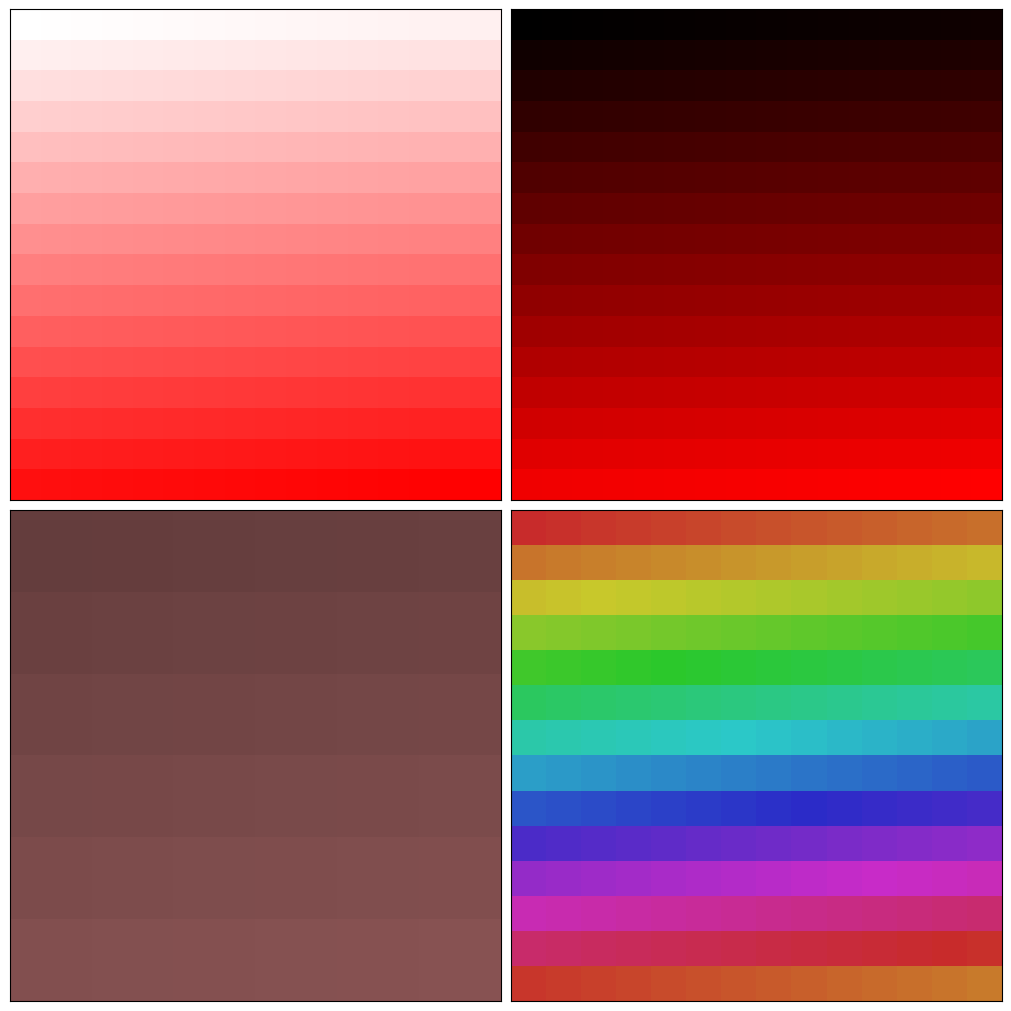

In [66]:
h = 180
img_sat = np.empty((16, 16, 3), dtype=np.uint8)
img_sat[..., 0] = h
img_sat[..., 1] = np.arange(256).reshape(16, 16)
img_sat[..., 2] = 255
img_sat = cv.cvtColor(img_sat, cv.COLOR_HSV2RGB)

img_val = np.empty((16, 16, 3), dtype=np.uint8)
img_val[..., 0] = h
img_val[..., 1] = 255
img_val[..., 2] = np.arange(256).reshape(16, 16)
img_val = cv.cvtColor(img_val, cv.COLOR_HSV2RGB)

cus = 100
img_cus = np.empty((6, 6, 3), dtype=np.uint8)
img_cus[..., 0] = h
img_cus[..., 1] = cus
img_cus[..., 2] = np.arange(cus, cus + 36).reshape(6, 6)
# img_cus[..., 2] = np.arange(cus, cus + 36).reshape(6, 6)
img_cus = cv.cvtColor(img_cus, cv.COLOR_HSV2RGB)

img_h = np.empty((14, 14, 3), dtype=np.uint8)
img_h[..., 0] = np.arange(196).reshape(14, 14)
img_h[..., 1] = 200
img_h[..., 2] = 200
img_h = cv.cvtColor(img_h, cv.COLOR_HSV2RGB)
# img_h = np.empty((1, 179-160, 3), dtype=np.uint8)
# img_h[..., 0] = np.arange(160, 179)
# img_h[..., 1] = 255
# img_h[..., 2] = 255
# img_h = cv.cvtColor(img_h, cv.COLOR_HSV2RGB)


fig, ax = plt.subplots(2,2, figsize=(10, 10), layout='constrained')
ax = ax.ravel()
for i, img in enumerate((img_sat, img_val, img_cus, img_h)):
    ax[i].imshow(img)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.show()